PRODUCTOS DISPONIBLES SELECCIONADOS PARA EVALUACION:
1. VITAMINA C+ZINC+D3
2. ENALAPRIL 10MG
3. METFORMINA 850MG
4. LOSARTAN 50MG
5. PARACETAMOL 500MG
6. CETIRIZINA 10MG
7. NAPROXENO TABX550MG
8. AZITROMICINA 500MG
9. AMOXICILINA 500MG
10. DIMENHIDRINATO 50MG
11. LORATADINA 10MG
12. OMEPRAZOL 20MG
13. IBUPROFENO TABX800
14. LOPERAMIDA 2MG
------------------------------------------------------------
DIAGNOSTICO: VITAMINA C+ZINC+D3
Total semanas: 135 | Semanas en cero absoluto: 3 (2.2%)


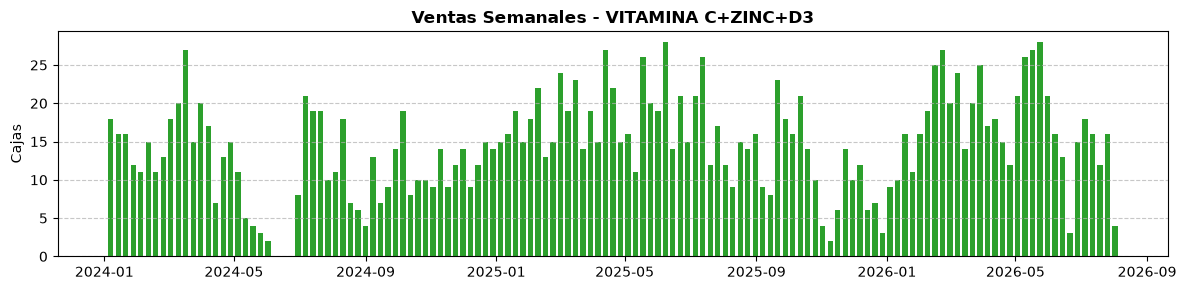

------------------------------------------------------------
DIAGNOSTICO: ENALAPRIL 10MG
Total semanas: 135 | Semanas en cero absoluto: 18 (13.3%)


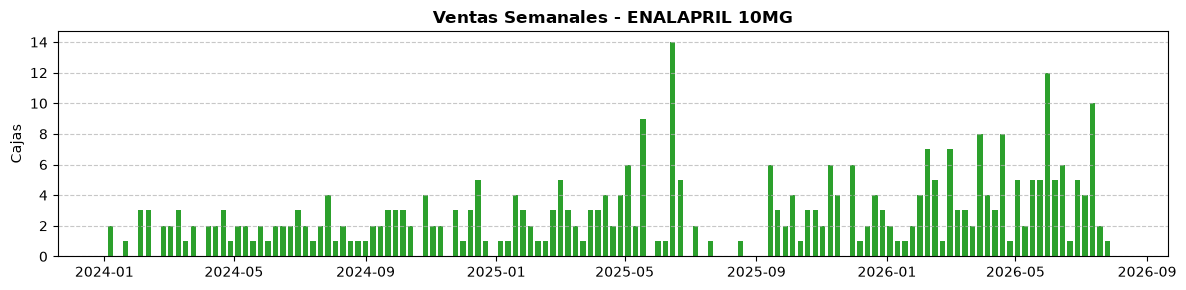

------------------------------------------------------------
DIAGNOSTICO: METFORMINA 850MG
Total semanas: 135 | Semanas en cero absoluto: 31 (23.0%)


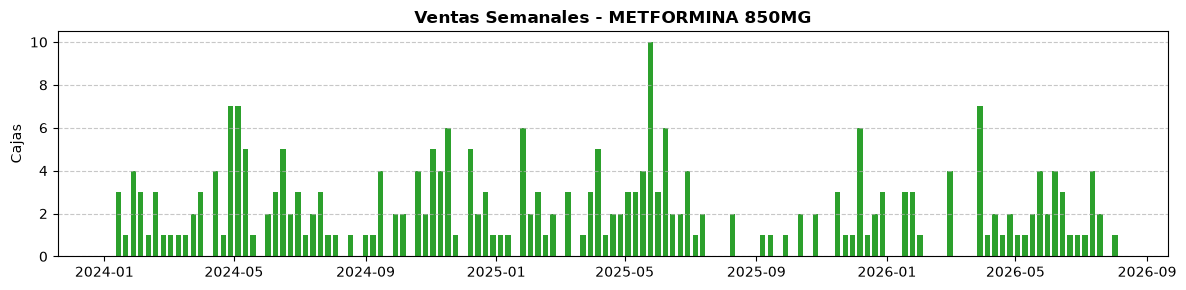

------------------------------------------------------------
DIAGNOSTICO: LOSARTAN 50MG
Total semanas: 108 | Semanas en cero absoluto: 26 (24.1%)


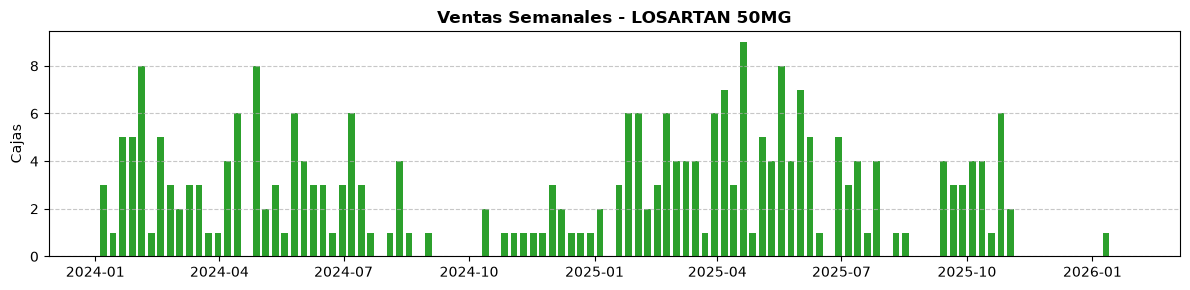

------------------------------------------------------------
DIAGNOSTICO: PARACETAMOL 500MG
Total semanas: 135 | Semanas en cero absoluto: 105 (77.8%)


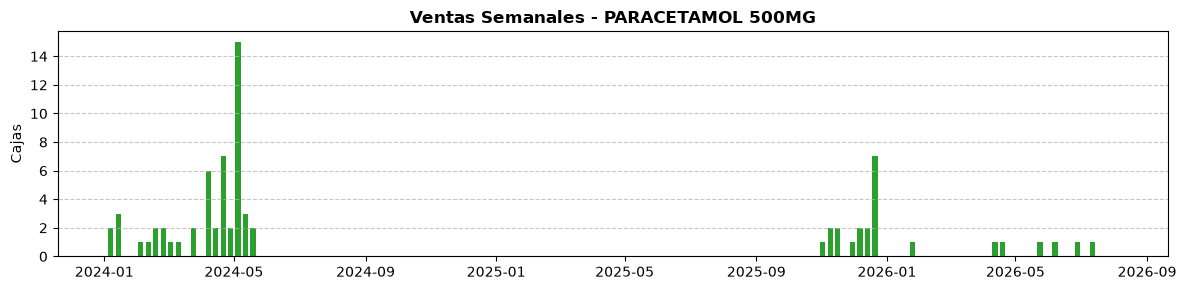

------------------------------------------------------------
DIAGNOSTICO: CETIRIZINA 10MG
Total semanas: 99 | Semanas en cero absoluto: 57 (57.6%)


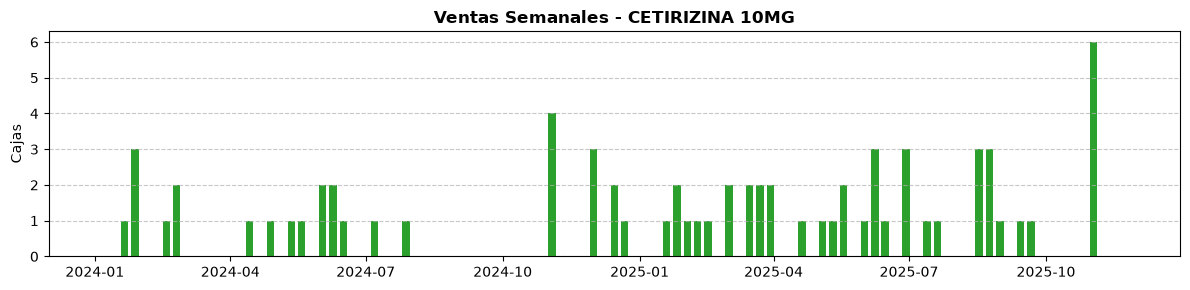

------------------------------------------------------------
DIAGNOSTICO: NAPROXENO TABX550MG
Total semanas: 104 | Semanas en cero absoluto: 61 (58.7%)


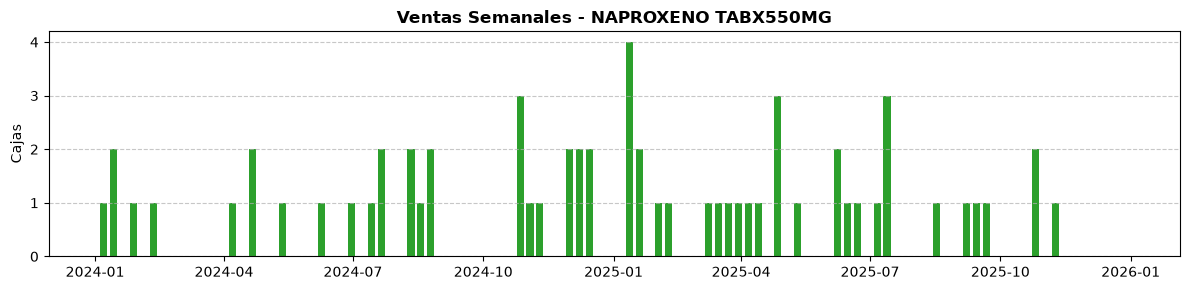

------------------------------------------------------------
DIAGNOSTICO: AZITROMICINA 500MG
Total semanas: 135 | Semanas en cero absoluto: 111 (82.2%)


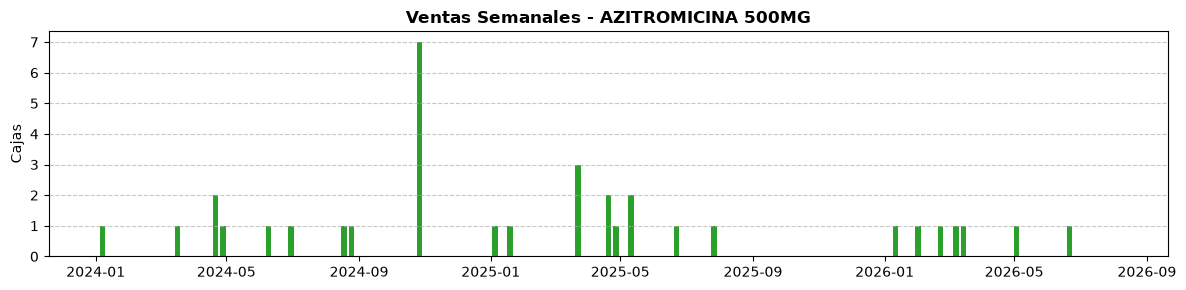

------------------------------------------------------------
DIAGNOSTICO: AMOXICILINA 500MG
Total semanas: 117 | Semanas en cero absoluto: 95 (81.2%)


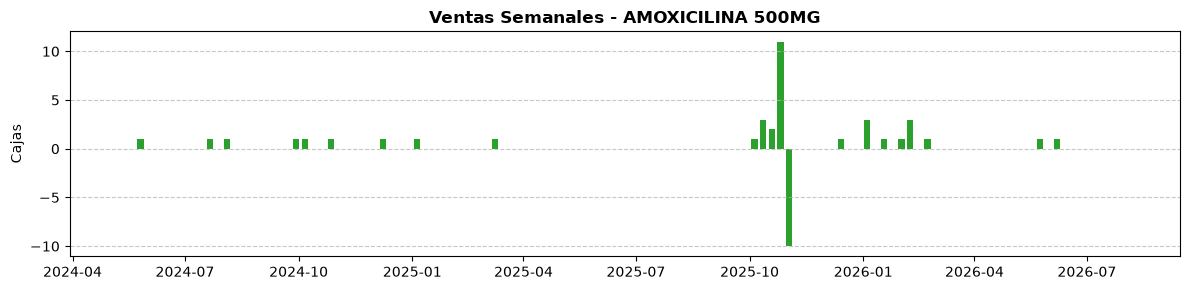

------------------------------------------------------------
DIAGNOSTICO: DIMENHIDRINATO 50MG
Total semanas: 135 | Semanas en cero absoluto: 116 (85.9%)


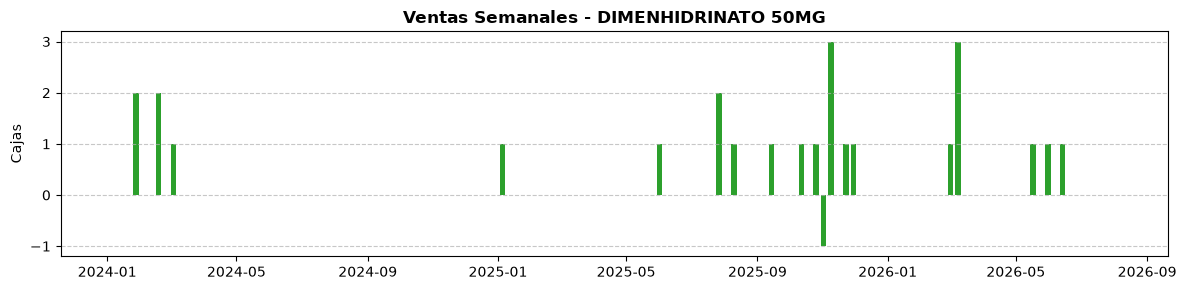

------------------------------------------------------------
DIAGNOSTICO: LORATADINA 10MG
Total semanas: 107 | Semanas en cero absoluto: 100 (93.5%)


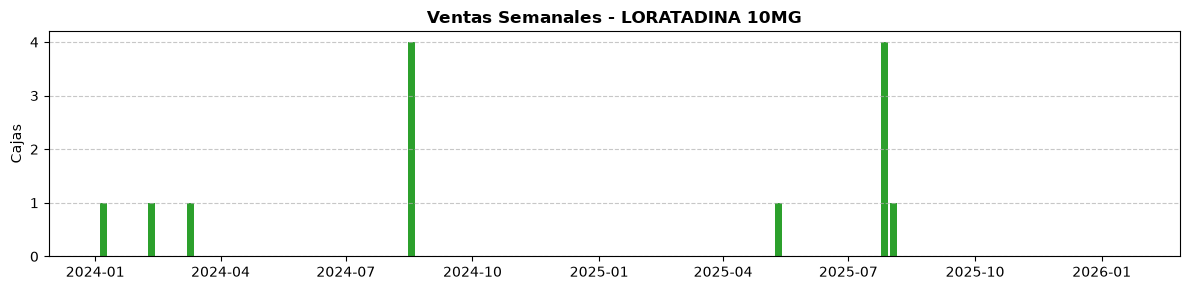

------------------------------------------------------------
DIAGNOSTICO: OMEPRAZOL 20MG
Total semanas: 85 | Semanas en cero absoluto: 78 (91.8%)


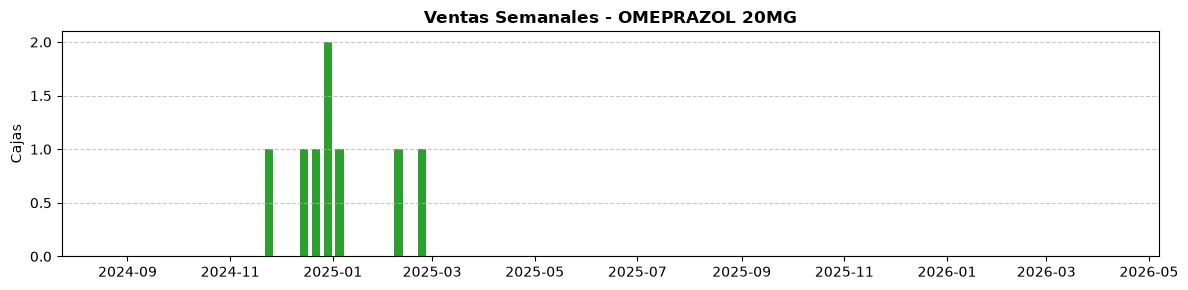

------------------------------------------------------------
DIAGNOSTICO: IBUPROFENO TABX800
Total semanas: 135 | Semanas en cero absoluto: 129 (95.6%)


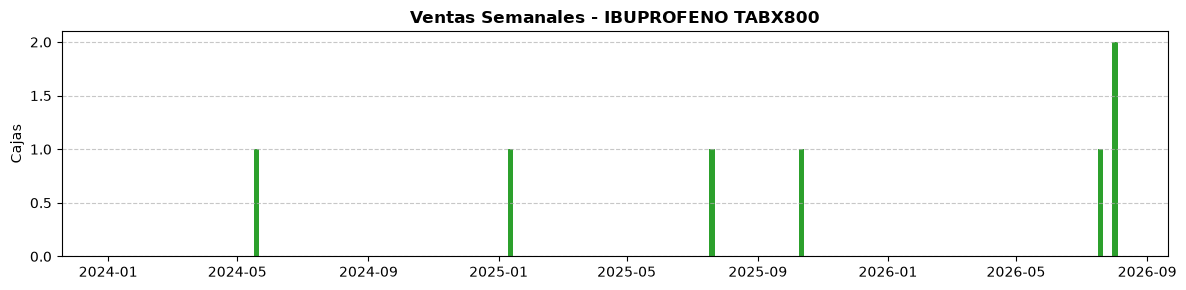

------------------------------------------------------------
DIAGNOSTICO: LOPERAMIDA 2MG
Total semanas: 135 | Semanas en cero absoluto: 131 (97.0%)


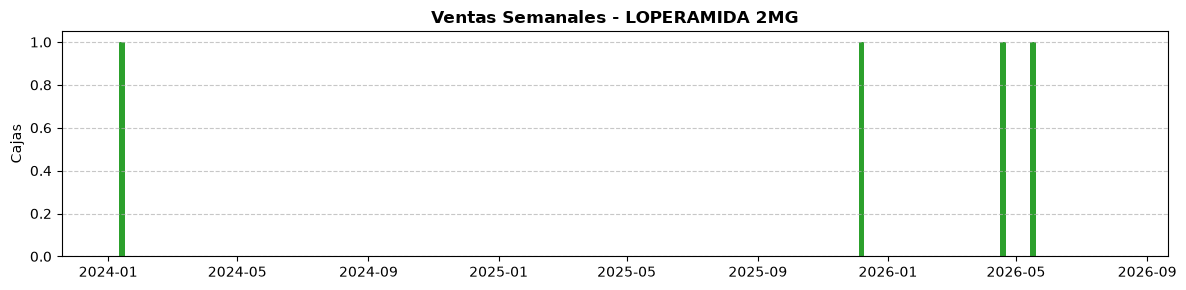

------------------------------------------------------------


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# 1. Leer los datos procesados del directorio
ruta_carpeta = "../datasets/final/" 
archivos = glob.glob(os.path.join(ruta_carpeta, "*_final.csv"))

lista_dfs = []
for archivo in archivos:
    df_temp = pd.read_csv(archivo)
    nombre_producto = os.path.basename(archivo).split('(')[0].replace('_final.csv', '').strip()
    df_temp['producto'] = nombre_producto
    lista_dfs.append(df_temp)

df_maestro = pd.concat(lista_dfs, ignore_index=True)
df_maestro['fecdoc'] = pd.to_datetime(df_maestro['fecdoc'])

# 2. Seleccionar los 14 productos disponibles por volumen (no implica categoría A)
df_volumen = df_maestro.groupby('producto')['cantidad'].sum().reset_index()
top_14_productos = df_volumen.sort_values(by='cantidad', ascending=False).head(14)['producto'].tolist()

print("PRODUCTOS DISPONIBLES SELECCIONADOS PARA EVALUACION:")
for i, prod in enumerate(top_14_productos, 1):
    print(f"{i}. {prod}")
print("-" * 60)

# 3. Funcion de analisis de intermitencia
def analizar_intermitencia(producto_objetivo):
    df_prod = df_maestro[df_maestro['producto'] == producto_objetivo]
    
    # Agrupar ventas por semana
    df_semanal = df_prod.set_index('fecdoc').resample('W')['cantidad'].sum().reset_index()
    
    # Rellenar semanas sin ventas con 0 explícitamente
    fechas_completas = pd.date_range(start=df_semanal['fecdoc'].min(), end=df_semanal['fecdoc'].max(), freq='W')
    df_semanal = df_semanal.set_index('fecdoc').reindex(fechas_completas, fill_value=0).reset_index()
    df_semanal.rename(columns={'index': 'fecdoc'}, inplace=True)
    
    # Calcular metricas clave
    total_semanas = len(df_semanal)
    semanas_cero = len(df_semanal[df_semanal['cantidad'] == 0])
    ceros_pct = (semanas_cero / total_semanas) * 100 if total_semanas > 0 else 0
    
    print(f"DIAGNOSTICO: {producto_objetivo}")
    print(f"Total semanas: {total_semanas} | Semanas en cero absoluto: {semanas_cero} ({ceros_pct:.1f}%)")
    
    # Grafico de barras para visualizar volatilidad vs intermitencia
    plt.figure(figsize=(12, 3))
    plt.bar(df_semanal['fecdoc'], df_semanal['cantidad'], color='#2ca02c', width=5)
    plt.title(f'Ventas Semanales - {producto_objetivo}', fontsize=12, fontweight='bold')
    plt.ylabel('Cajas')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 4. Bucle de analisis exclusivo para los 14 productos
for prod in top_14_productos:
    analizar_intermitencia(prod)
    print("-" * 60)
    

## Demanda cero e intermitencia por sucursal-producto
Se conserva la frecuencia semanal (`W`, cierre en domingo). Cada serie encontrada se observa entre su primera y última semana registrada; las semanas interiores sin registros se completan con cero. No se imputan ceros fuera de ese intervalo ni para combinaciones nunca observadas.

Los ceros se refieren a `cantidad` (cajas): existen registros con cajas cero y `unidades` positivas, por lo que no equivalen necesariamente a ausencia de ventas o demanda. El ADI descriptivo se calcula como semanas observadas / semanas con cantidad positiva; queda indefinido si no hay semanas positivas. Se muestran por separado los casos Enalapril 10MG, Metformina 850MG y Losartan 50MG.

Series sucursal-producto encontradas: 240


,sucursal,producto,inicio,fin,semanas,semanas_cero,porcentaje_cero,semanas_positivas,adi_semanas,max_racha_cero,cantidad_total,registros_cajas_cero_con_unidades
5,1,IBUPROFENO TABX800,2024-01-07,2026-07-19,133,133,100.000000,0,NaN,133,0.0,141
17,2,DIMENHIDRINATO 50MG,2024-02-04,2026-08-02,131,131,100.000000,0,NaN,131,0.0,105
20,2,LOPERAMIDA 2MG,2026-01-25,2026-07-26,27,27,100.000000,0,NaN,27,0.0,37
29,3,AZITROMICINA 500MG,2024-01-07,2026-06-07,127,127,100.000000,0,NaN,127,0.0,215
34,3,LOPERAMIDA 2MG,2024-01-21,2026-07-19,131,131,100.000000,0,NaN,131,0.0,38
35,3,LORATADINA 10MG,2024-01-07,2026-01-18,107,107,100.000000,0,NaN,107,0.0,180
39,3,OMEPRAZOL 20MG,2024-09-15,2025-03-16,27,27,100.000000,0,NaN,27,0.0,29
43,4,AZITROMICINA 500MG,2024-01-07,2026-08-02,135,135,100.000000,0,NaN,135,0.0,175
47,4,IBUPROFENO TABX800,2024-01-07,2026-07-19,133,133,100.000000,0,NaN,133,0.0,111
48,4,LOPERAMIDA 2MG,2024-01-28,2026-08-02,132,132,100.000000,0,NaN,132,0.0,4


CASO: ENALAPRIL 10MG | Sucursales encontradas: 19


,sucursal,producto,inicio,fin,semanas,semanas_cero,porcentaje_cero,semanas_positivas,adi_semanas,max_racha_cero,cantidad_total,registros_cajas_cero_con_unidades
4,1,ENALAPRIL 10MG,2024-01-07,2026-07-26,134,95,70.895522,39,3.435897,12,48.0,150
18,2,ENALAPRIL 10MG,2024-01-07,2026-07-26,134,101,75.373134,33,4.060606,19,37.0,160
32,3,ENALAPRIL 10MG,2024-01-21,2026-08-02,133,109,81.954887,24,5.541667,22,28.0,181
46,4,ENALAPRIL 10MG,2024-01-14,2026-07-26,133,113,84.962406,20,6.650000,20,22.0,137
59,5,ENALAPRIL 10MG,2024-01-28,2026-07-26,131,99,75.572519,32,4.093750,16,36.0,158
73,6,ENALAPRIL 10MG,2024-01-07,2026-08-02,135,120,88.888889,15,9.000000,32,36.0,189
87,7,ENALAPRIL 10MG,2024-01-07,2026-07-26,134,120,89.552239,14,9.571429,25,14.0,133
100,8,ENALAPRIL 10MG,2024-01-07,2026-07-19,133,126,94.736842,7,19.000000,37,7.0,60
114,9,ENALAPRIL 10MG,2024-01-07,2026-07-26,134,118,88.059701,16,8.375000,22,16.0,191
128,10,ENALAPRIL 10MG,2024-01-07,2026-07-26,134,95,70.895522,39,3.435897,11,42.0,123


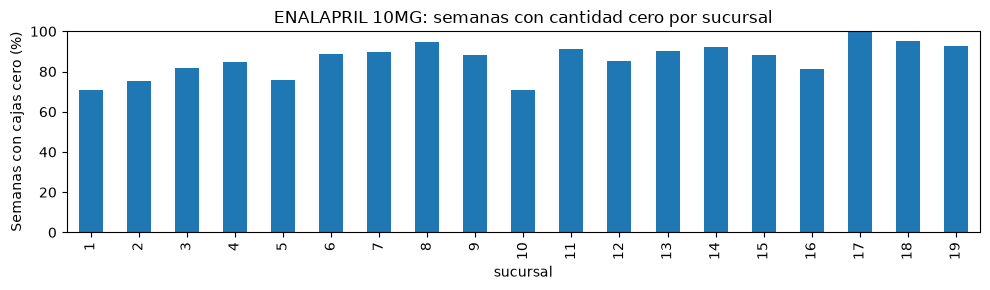

CASO: METFORMINA 850MG | Sucursales encontradas: 19


,sucursal,producto,inicio,fin,semanas,semanas_cero,porcentaje_cero,semanas_positivas,adi_semanas,max_racha_cero,cantidad_total,registros_cajas_cero_con_unidades
9,1,METFORMINA 850MG,2024-01-28,2026-06-14,125,100,80.000000,25,5.000000,19,34.0,33
23,2,METFORMINA 850MG,2024-01-07,2026-06-28,130,110,84.615385,20,6.500000,41,25.0,27
37,3,METFORMINA 850MG,2024-01-14,2026-06-21,128,115,89.843750,13,9.846154,26,39.0,14
51,4,METFORMINA 850MG,2024-03-17,2026-08-02,125,113,90.400000,12,10.416667,42,14.0,31
64,5,METFORMINA 850MG,2024-01-21,2026-07-12,130,106,81.538462,24,5.416667,24,32.0,51
78,6,METFORMINA 850MG,2024-01-07,2026-07-26,134,113,84.328358,21,6.380952,62,26.0,22
92,7,METFORMINA 850MG,2024-01-07,2026-08-02,135,129,95.555556,6,22.500000,47,6.0,39
105,8,METFORMINA 850MG,2024-01-07,2026-08-02,135,129,95.555556,6,22.500000,82,7.0,35
119,9,METFORMINA 850MG,2024-01-28,2026-08-02,132,122,92.424242,10,13.200000,53,15.0,32
133,10,METFORMINA 850MG,2024-01-14,2026-02-15,110,100,90.909091,10,11.000000,30,12.0,25


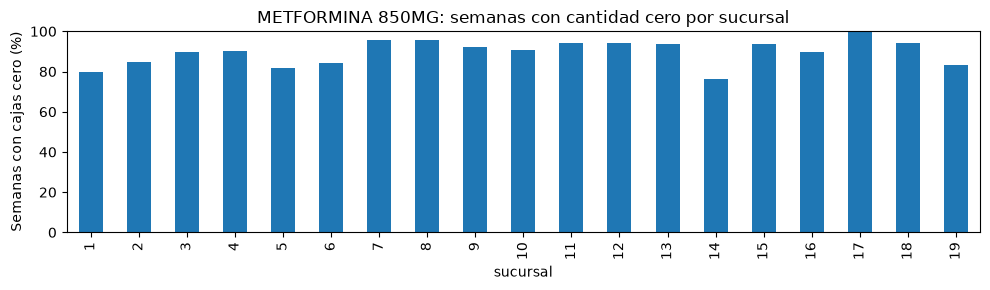

CASO: LOSARTAN 50MG | Sucursales encontradas: 16


,sucursal,producto,inicio,fin,semanas,semanas_cero,porcentaje_cero,semanas_positivas,adi_semanas,max_racha_cero,cantidad_total,registros_cajas_cero_con_unidades
8,1,LOSARTAN 50MG,2024-01-07,2025-11-09,97,60,61.855670,37,2.621622,15,58.0,221
22,2,LOSARTAN 50MG,2024-01-07,2025-11-09,97,80,82.474227,17,5.705882,18,20.0,125
36,3,LOSARTAN 50MG,2024-01-07,2026-01-25,108,88,81.481481,20,5.400000,18,24.0,231
50,4,LOSARTAN 50MG,2024-01-07,2025-11-02,96,69,71.875000,27,3.555556,15,36.0,144
63,5,LOSARTAN 50MG,2024-01-07,2025-10-26,95,65,68.421053,30,3.166667,25,40.0,175
77,6,LOSARTAN 50MG,2024-01-07,2025-11-09,97,86,88.659794,11,8.818182,23,13.0,253
91,7,LOSARTAN 50MG,2024-01-07,2025-11-09,97,87,89.690722,10,9.700000,17,10.0,174
104,8,LOSARTAN 50MG,2024-01-07,2025-10-26,95,87,91.578947,8,11.875000,30,9.0,87
118,9,LOSARTAN 50MG,2024-01-07,2025-11-02,96,80,83.333333,16,6.000000,28,16.0,161
132,10,LOSARTAN 50MG,2024-01-07,2025-11-09,97,83,85.567010,14,6.928571,21,15.0,125


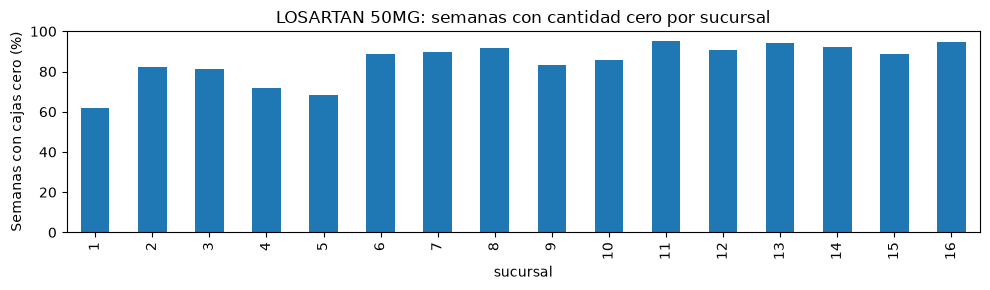

In [2]:
filas_intermitencia = []
for (sucursal, producto), grupo in df_maestro.groupby(['sucursal', 'producto']):
    semanal = grupo.set_index('fecdoc')['cantidad'].resample('W').sum().fillna(0)
    semanas = len(semanal)
    semanas_cero = int(semanal.eq(0).sum())
    semanas_positivas = int(semanal.gt(0).sum())
    rachas = semanal.eq(0).astype(int).groupby(semanal.ne(0).cumsum()).sum()
    filas_intermitencia.append({
        'sucursal': sucursal, 'producto': producto,
        'inicio': semanal.index.min(), 'fin': semanal.index.max(),
        'semanas': semanas, 'semanas_cero': semanas_cero,
        'porcentaje_cero': semanas_cero / semanas * 100,
        'semanas_positivas': semanas_positivas,
        'adi_semanas': semanas / semanas_positivas if semanas_positivas else np.nan,
        'max_racha_cero': int(rachas.max()),
        'cantidad_total': semanal.sum(),
        'registros_cajas_cero_con_unidades': int((grupo['cantidad'].eq(0) & grupo['unidades'].gt(0)).sum())
    })
resumen_intermitencia = pd.DataFrame(filas_intermitencia).sort_values(
    ['porcentaje_cero', 'sucursal', 'producto'], ascending=[False, True, True])
print(f'Series sucursal-producto encontradas: {len(resumen_intermitencia)}')
with pd.option_context('display.max_rows', None):
    display(resumen_intermitencia)

casos = ['ENALAPRIL 10MG', 'METFORMINA 850MG', 'LOSARTAN 50MG']
for producto in casos:
    detalle = resumen_intermitencia[resumen_intermitencia['producto'].eq(producto)].sort_values('sucursal')
    print(f'CASO: {producto} | Sucursales encontradas: {len(detalle)}')
    display(detalle)
    if not detalle.empty:
        detalle.plot.bar(x='sucursal', y='porcentaje_cero', legend=False, figsize=(10, 3))
        plt.title(f'{producto}: semanas con cantidad cero por sucursal')
        plt.ylabel('Semanas con cajas cero (%)')
        plt.ylim(0, 100)
        plt.tight_layout()
        plt.show()
